In [ ]:
# 

In [ ]:
# Importamos módulos 
from radunc import radunc as rdc
from radunc import plot_error_prob as prb
from radunc import get_unct as unct

# Importamos librerías generales
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

In [2]:
TIF_PATH = 'data_test/envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub_SpkGamma11.tif'
SAMPLES_PATH = 'muestras_merged4326.geojson'
SAMPLES_COL = 'nombre'
LIST_PROBS = [50, 90, 95]

In [3]:
# --
scene_test = rio.open(TIF_PATH)
gpd_samples = gpd.read_file(SAMPLES_PATH)

# --
gpd_samples_rep = gpd_samples.to_crs(scene_test.crs)

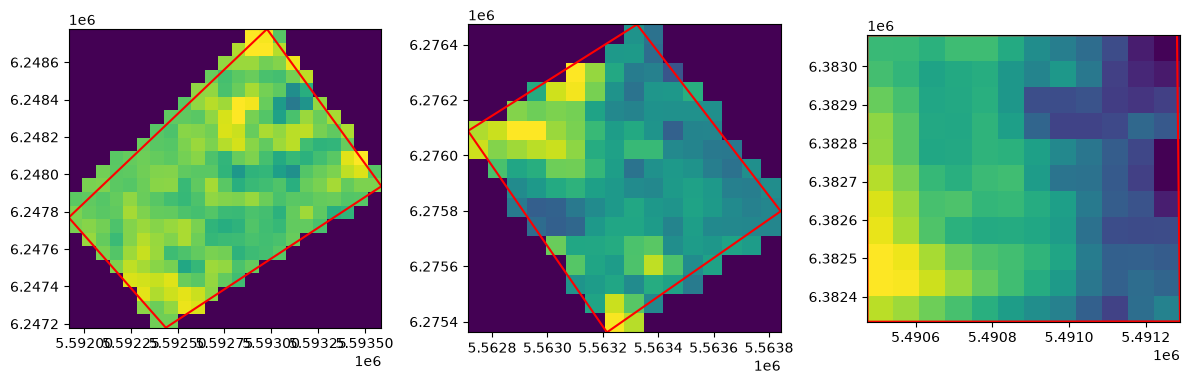

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

for idx, row in gpd_samples_rep.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    plot_extent = (minx, maxx, miny, maxy)
    
    scene_mask, mask_transform = mask(dataset=scene_test, shapes = [row.geometry], all_touched=True, crop = True)
    ax[idx].imshow(scene_mask[0], cmap='viridis', 
                   vmin = np.nanpercentile(scene_mask[0], 1), vmax = np.nanpercentile(scene_mask[0], 99),
                   extent = plot_extent)
    
    gpd.GeoSeries([row.geometry]).plot(ax=ax[idx], edgecolor='red', linewidth=1.5, facecolor='none')
    

In [6]:
rdc(TIF_PATH, SAMPLES_PATH, SAMPLES_COL, LIST_PROBS)

/home/franco-barrionuevo/Documents/GitHub/MAIE_devs_pub/SAR/Mercedes/TP4 Filtros/radiometric_uncertainty/radunc.py:115: UserWarning: CRS mismatch: samples CRS (EPSG:4326) does not match raster CRS (PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",-60],PARAMETER["scale_factor",1],PARAMETER["false_easting",5500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]). Reprojecting samples to match raster.
  gdf_samples = read_check_vector(tif_path, samples_path)


,Sample,Mean,Std,ENL,Rad. Unc. 50 [dB],Real. Prob. 50 [%],Rad. Unc. 90 [dB],Real. Prob. 90 [%],Rad. Unc. 95 [dB],Real. Prob. 95 [%]
0,forestacion3,0.088746,0.011654,57.984505,0.39,50.52,0.94,89.92,1.13,95.09
1,juncal4,0.576780,0.166235,12.038620,0.85,49.94,2.10,89.93,2.54,95.02
2,laguna5,0.005137,0.000215,573.285950,0.12,49.17,0.30,90.17,0.36,95.27


In [4]:
ENL = 4

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Probability vs Radiometric Uncertainty - ENL:4'}, xlabel='Radiometric Uncertainty (dB)', ylabel='Probability (%)'>)

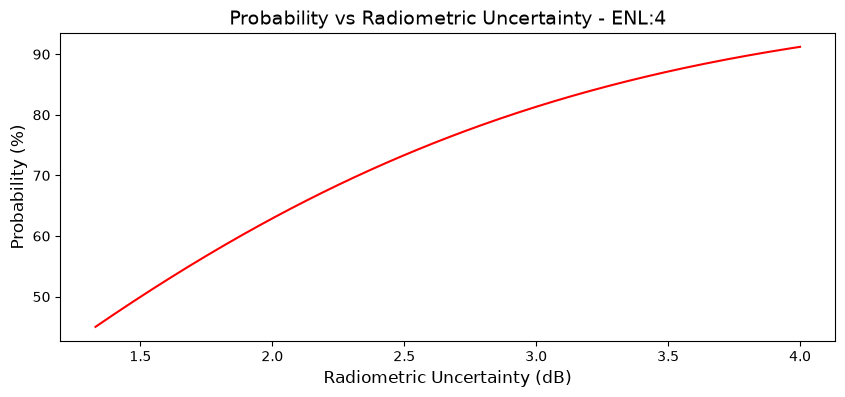

In [5]:
prb(ENL)